In [1]:
import pandas as pd


In [2]:
df = pd.read_csv("shipments.csv", parse_dates=["timestamp"])

In [3]:
df.head()

,shipment_id,timestamp,severity,thread,source,event,station,box_barcode,articles,exp_weight_kg,...,abs_weight_diff,print_quality_pct,line_speed_mps,slam,iso_grade,pckg_problem_found,weight_diff,weight_diff_ratio,distance_to_threshold,is_kot
0,Sp260320125716,2026-01-12 00:02:12.737,INFO,LabelThread-4,com.logistic.labelmachine.SystemManager,Label printed,Station-06,BC_LARGE400,2.0,4.370,...,0.01704,100.00000,1.40,SLAM5_LP1,A,NaN,0.01704,0.004,-0.035400,0
1,Sp260320125717,2026-01-12 00:02:26.481,INFO,LabelThread-2,com.logistic.labelmachine.SystemManager,Label printed,Station-07,RK_SMALL90,18.0,2.507,...,0.02557,99.96875,1.39,SLAM5_LP2,A,NaN,0.02557,0.010,-0.004514,0
2,Sp260320125718,2026-01-12 00:02:39.520,INFO,LabelThread-1,com.logistic.labelmachine.SystemManager,Label printed,Station-03,RK_SMALL90,9.0,1.770,...,0.00850,99.91250,1.67,SLAM5_LP1,A,NaN,0.00850,0.005,-0.012740,0
3,Sp260320125719,2026-01-12 00:02:51.721,INFO,LabelThread-3,com.logistic.labelmachine.SystemManager,Label printed,Station-03,BC_SMALL100,12.0,2.382,...,0.01524,99.88125,2.07,SLAM5_LP2,A,NaN,-0.01524,0.006,-0.013344,0
4,Sp260320125720,2026-01-12 00:03:05.377,INFO,main,com.logistic.labelmachine.SystemManager,Package processed successfully,Station-04,BC_SMALL100,16.0,5.291,...,0.06243,99.82500,1.96,SLAM5_LP1,A,NaN,0.06243,0.012,-0.001062,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5893 entries, 0 to 5892
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   shipment_id            5893 non-null   object        
 1   timestamp              5893 non-null   datetime64[ns]
 2   severity               5893 non-null   object        
 3   thread                 5893 non-null   object        
 4   source                 5893 non-null   object        
 5   event                  5893 non-null   object        
 6   station                5750 non-null   object        
 7   box_barcode            5893 non-null   object        
 8   articles               5750 non-null   float64       
 9   exp_weight_kg          5750 non-null   float64       
 10  act_weight_kg          5750 non-null   float64       
 11  tare_weight_kg         5750 non-null   float64       
 12  product_weight_kg      5750 non-null   float64       
 13  abs

In [5]:
df.describe()

,timestamp,articles,exp_weight_kg,act_weight_kg,tare_weight_kg,product_weight_kg,abs_weight_diff,print_quality_pct,line_speed_mps,weight_diff,weight_diff_ratio,distance_to_threshold,is_kot
count,5893,5750.000000,5750.000000,5750.000000,5750.000000,5750.000000,5750.000000,4425.000000,4425.000000,5750.000000,5750.000000,5750.000000,5893.000000
mean,2026-01-12 11:27:27.933169920,10.686435,3.164804,3.311188,0.144376,3.166812,0.045860,94.037181,1.604050,-0.002008,0.014462,0.007882,0.224843
min,2026-01-12 00:02:12.737000,1.000000,0.380000,0.453980,0.070000,0.376880,0.001260,88.012500,0.800000,-0.375580,0.003000,-0.053336,0.000000
25%,2026-01-12 05:34:05.548000,6.000000,1.752250,1.885728,0.090000,1.755143,0.014105,91.018750,1.220000,-0.027487,0.006000,-0.017837,0.000000
50%,2026-01-12 11:11:04.294000128,11.000000,3.152000,3.290175,0.120000,3.155590,0.026035,94.050000,1.600000,-0.002940,0.009000,-0.006982,0.000000
75%,2026-01-12 17:01:33.876000,16.000000,4.556750,4.692723,0.240000,4.560837,0.047685,97.056250,2.000000,0.024990,0.012000,-0.000487,0.000000
max,2026-01-12 23:59:11.540000,20.000000,6.000000,6.518040,0.290000,6.327000,0.375580,100.000000,2.400000,0.370550,0.065000,0.306028,1.000000
std,NaN,5.759179,1.619009,1.626837,0.074294,1.622971,0.058032,3.487986,0.457555,0.073940,0.014837,0.053153,0.417514


## **Analyse: Einfluss der Schichtzeiten auf Maschinenleistung**

Gibt es Auffälligkeiten zwischen den Schichten (Früh, Spät, Nacht), die einen Einfluss auf die Maschinenleistung und Produktivität haben?

Dabei wird untersucht, ob sich die Fehlerquote (Kickout-Rate) und die Produktivität zwischen den Schichten unterscheiden.

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# ==============================
# 1. Vorbereitung
# ==============================

df = df.copy()

df["timestamp"] = pd.to_datetime(df["timestamp"])
df["hour"] = df["timestamp"].dt.hour


In [7]:
# 2. Schichten definieren
# ==============================
df["hour"] = df["timestamp"].dt.hour
conditions = [
    (df["hour"]>=22) |  (df["hour"]<6),
    (df["hour"]>=6)  & (df["hour"]<14),
    (df["hour"]>=14) & (df["hour"]<22)
]
choices = [
    "Nachschicht",
    "Frühschicht",
    "Spätschicht"
]
df["shift"] = np.select(conditions, choices, default="unbekannt")


In [8]:
# ==============================
# 3. KPI-Tabelle pro Schicht
# ==============================

shift_kpis = df.groupby("shift").agg(
    total_shipments=("shipment_id", "count"),
    kickouts=("is_kot", "sum"),
    kickout_rate=("is_kot", "mean"),
    avg_speed=("line_speed_mps", "mean")
).reset_index()

shift_kpis = shift_kpis.sort_values(by="kickout_rate", ascending=False)

print(shift_kpis)




         shift  total_shipments  kickouts  kickout_rate  avg_speed
0  Frühschicht             2109       488      0.231389   1.599822
1  Nachschicht             2041       472      0.231259   1.613837
2  Spätschicht             1743       365      0.209409   1.597915


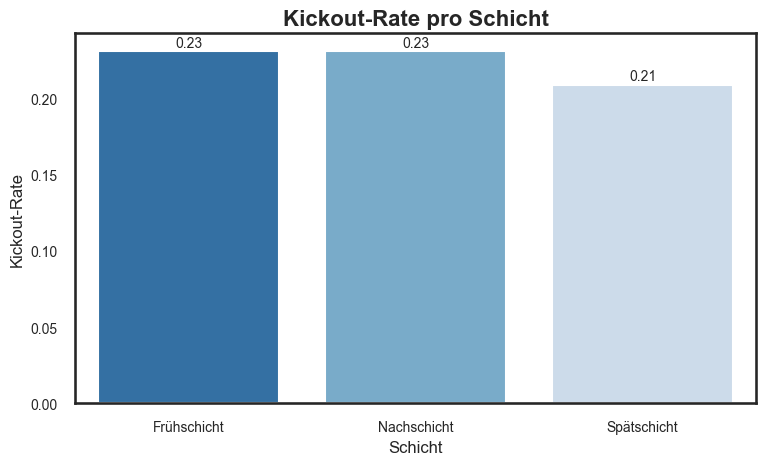

In [9]:
# ==============================
# 4. Plot
# ==============================

sns.set_style("white")
sns.set_context("talk")

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=shift_kpis,
    x="shift",
    y="kickout_rate",
    hue="shift",
    palette="Blues_r",
    legend=False
)

plt.title("Kickout-Rate pro Schicht", fontsize=16, weight="bold")
plt.xlabel("Schicht", fontsize=12)
plt.ylabel("Kickout-Rate", fontsize=12)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

for i, v in enumerate(shift_kpis["kickout_rate"]):
    ax.text(i, v + 0.003, f"{v:.2f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()




In [10]:
# ==============================
# 5. KPI Summary (für Dashboard)
# ==============================

avg_kickout = shift_kpis["kickout_rate"].mean()
worst_shift = shift_kpis.iloc[0]["shift"]
best_shift = shift_kpis.iloc[-1]["shift"]

print("\n===== KPI SUMMARY =====")
print(f"Durchschnittliche Kickout-Rate: {avg_kickout:.3f}")
print(f"Schlechteste Schicht: {worst_shift}")
print(f"Beste Schicht: {best_shift}")





===== KPI SUMMARY =====
Durchschnittliche Kickout-Rate: 0.224
Schlechteste Schicht: Frühschicht
Beste Schicht: Spätschicht




## **Fazit: Schichtvergleich**

Die Analyse zeigt keine signifikanten Unterschiede in der Kickout-Rate zwischen den einzelnen Schichten (Früh-, Spät- und Nachtschicht).

Die Fehlerquote bleibt über alle Schichten hinweg auf einem vergleichbaren Niveau, sodass kein klarer Einfluss der Schichtzugehörigkeit auf die Maschinenleistung festgestellt werden kann.

Auch hinsichtlich der Produktivität ergeben sich keine auffälligen Abweichungen.

**Ergebnis:**
- Keine auffällige Schicht identifiziert  
- Maschinenleistung ist schichtunabhängig stabil  
- Kein Handlungsbedarf auf Schichtebene

## **Analyse: Einfluss der Schichtwechselzeiten auf Maschinenleistung**

Gibt es Auffälligkeiten rund um die Schichtwechselzeitpunkte (06:00, 14:00, 22:00 Uhr), die einen Einfluss auf die Maschinenleistung und Produktivität haben?

Dabei wird untersucht, ob es unmittelbar vor, während oder nach den Schichtwechseln zu Veränderungen in der Fehlerquote (Kickout-Rate), der Druckqualität oder der Verarbeitungsgeschwindigkeit kommt.

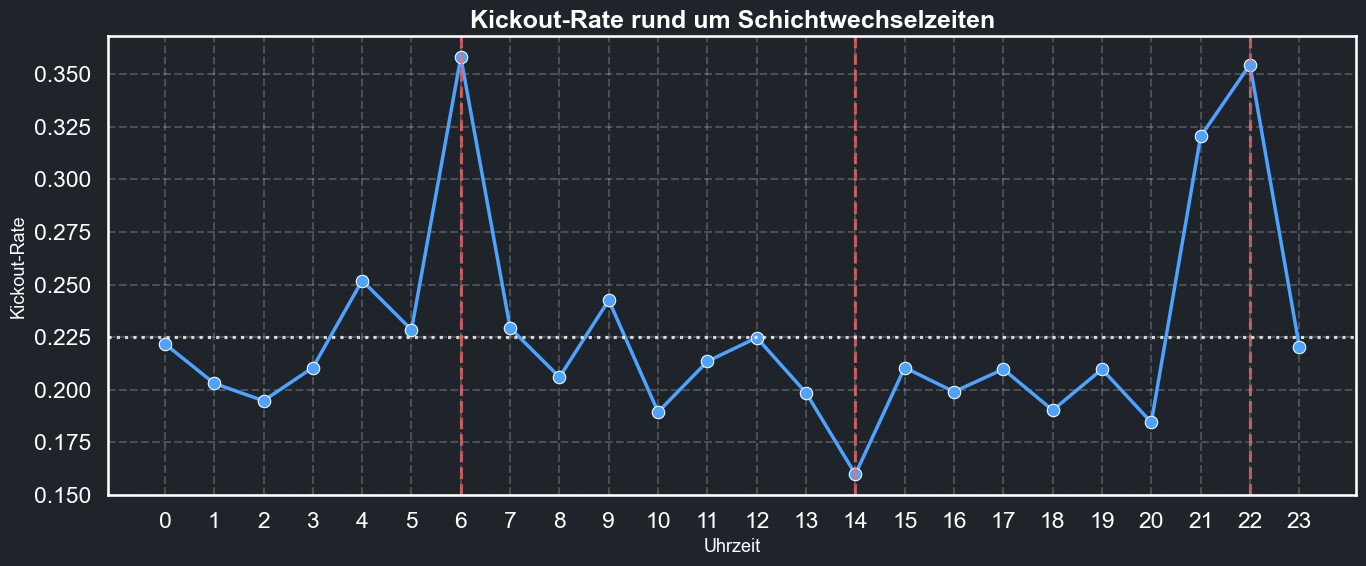

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# KPI berechnen
kickout_rate = df.groupby("hour")["is_kot"].mean().reset_index()

# Style (dark theme passend zur Folie)
plt.style.use("dark_background")
sns.set_context("talk")

fig, ax = plt.subplots(figsize=(14, 6))

# Hintergrund anpassen
fig.patch.set_facecolor("#1F242A")
ax.set_facecolor("#1F242A")

# Linie
sns.lineplot(
    data=kickout_rate,
    x="hour",
    y="is_kot",
    marker="o",
    color="#4DA3FF",
    linewidth=2.5,
    ax=ax
)

# Schichtwechsel markieren
for h in [6, 14, 22]:
    ax.axvline(x=h, linestyle="--", color="#FF6B6B", alpha=0.7)

# Durchschnittslinie
mean_val = df["is_kot"].mean()
ax.axhline(mean_val, linestyle=":", color="white", alpha=0.8)

# Titel & Labels
ax.set_title("Kickout-Rate rund um Schichtwechselzeiten", fontsize=18, weight="bold", color="white")
ax.set_xlabel("Uhrzeit", fontsize=13, color="white")
ax.set_ylabel("Kickout-Rate", fontsize=13, color="white")

# Achsen
ax.set_xticks(range(0, 24))
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

# Grid (leicht sichtbar)
ax.grid(True, linestyle="--", alpha=0.2)

# Layout
plt.tight_layout()

# SPEICHERN
plt.savefig("schichtwechsel.png", dpi=300, bbox_inches='tight', transparent=True)

plt.show()

## **Fazit: Schichtwechsel-Zeitpunkte**

Die Analyse der Kickout-Rate über den Tagesverlauf zeigt auffällige Veränderungen rund um einzelne Schichtwechsel-Zeitpunkte.

Insbesondere treten bei **06:00 Uhr** und **22:00 Uhr** deutliche Peaks in der Kickout-Rate auf, die über dem durchschnittlichen Niveau liegen. Der Schichtwechsel um **14:00 Uhr** zeigt hingegen keine vergleichbare Auffälligkeit.

Dies deutet darauf hin, dass nicht alle Schichtwechsel gleichermaßen kritisch sind, jedoch insbesondere die Übergänge um **06:00 Uhr** und **22:00 Uhr** mit einer erhöhten Fehlerquote verbunden sein könnten.

**Ergebnis:**
- Auffällige Peaks bei **06:00 Uhr** und **22:00 Uhr**
- Kein klarer Peak bei **14:00 Uhr**
- Hinweise auf mögliche Übergabe- oder Prozessprobleme bei einzelnen Schichtwechseln

## **Dashboard: Schichtwechsel-Zeitpunkte**

### **Hauptvisualisierung**
- Linienplot: Kickout-Rate über den Tagesverlauf
- Markierungen bei Schichtwechseln: 06:00, 14:00, 22:00

### **KPIs**
- Durchschnittliche Kickout-Rate: ~22%
- Auffällige Zeitpunkte: 06:00, 22:00
- Unauffälliger Schichtwechsel: 14:00

### **Insight**
Erhöhte Fehlerquoten treten insbesondere bei den Schichtwechseln um 06:00 und 22:00 Uhr auf. 
Dies deutet auf mögliche Übergabeprobleme oder Prozessinstabilitäten zu diesen Zeitpunkten hin.

## **Handlungsempfehlung: Schichtwechselzeiten**

- Übergabeprozesse zwischen Schichten standardisieren (Checklisten, feste Abläufe)
- Maschinenstatus vor Schichtwechsel aktiv prüfen (Kalibrierung, Druckqualität)
- Kurzzeitige Qualitätskontrolle nach Schichtstart einführen
- Schulung der Mitarbeiter für saubere Übergaben und Maschinenhandling